In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import sympy as sp
from IPython.display import HTML

# **Part 1: The Wave Equation**
We solve the wave equation
$$
\partial_t^2 u - c^2 \partial_x^2 u = f(t,x), \\
u(0,x) = u^0(x), \\
\partial_t u(0,x) = v^0(x)
$$
with periodic boundary conditions
$$
u(-L) = u(L).
$$



### Question 1
Implement the finite difference scheme above for the wave equation with periodic boundary conditions.

In [11]:
def solve_wave_equation():
  # U[i,n] approximates u(x_i, t_n)
  L = 10
  a = -L
  b = L
  c = 1
  T = L/(2*c)
  k=12

  f = lambda x,t: 0
  u_0 = lambda x: np.exp(-(x**2))
  v_0 = lambda x: 2*x*np.exp(-(x**2))
  M = 2**k

  h = (b-a) / (M)

  N = int(c * T / h)
  tau = T / N

  xs = [a + i * h for i in range(M + 1)]
  ts = [n * tau for n in range(N + 1)]

  U = np.zeros((M + 1, N + 1))

  # each timestep t_{n+1}, n = 1,...,N, we explicitly update U[:,n+1]

  # initialize t_0
  for i in range(1, M):
      U[i, 0] = u_0(xs[i])

  # boundary conditions at t_0
  U[0, 0] = u_0(xs[0])
  U[M, 0] = U[0, 0]

  # initialize t_1
  for i in range(1, M):
      U[i, 1] = U[i, 0] + tau*v_0(xs[i]) + (((c**2)*(tau**2))/(2*h**2))*(U[i+1, 0] - 2*U[i,0] + U[i-1, 0]) + (tau**2/2)*f(xs[i], ts[0])


  # boundary conditions at t_1
  U[0, 1] = U[0, 0] + tau*v_0(xs[0]) + (((c**2)*tau**2)/(2*h**2))*(U[1, 0] - 2*U[0, 0] + U[M-1, 0]) + ((tau**2)/2)*f(xs[0], ts[0])

  # explicit timestepping
  for n in range (1, N):
      for i in range(1, M):
          U[i, n + 1] = 2*U[i, n] - U[i, n - 1] + (((c**2)*(tau**2))/(h**2))*(U[i+1, n] - 2*U[i, n] + U[i-1, n]) + (tau**2)*f(xs[i],ts[n])

  # boundary conditions
  U[0, n+1] = 2*U[0, n] - U[0, n - 1] + (((c**2)*(tau**2))/(h**2))*(U[1, n] - 2*U[0, n] + U[M-1, n]) + (tau**2)*f(xs[0], ts[n])
  U[M, n+1] = U[0, n+1]
  return U

### Question 2
Test your code with the method of manufactured solutions.

Let $L = 10$, $c = 1$, $u(t,x) = \exp(-(x-ct)^2)$.
Compute the corresponding $f$, $u^0$, and $v^0$ such that $u$ solves the PDE.
Run until final time $T := L/(2c) = N\tau$.
        
Plot $U_i^N$ versus $u(t_N,x_i)$ at the grid points $x_i$ for the highest refinement level.

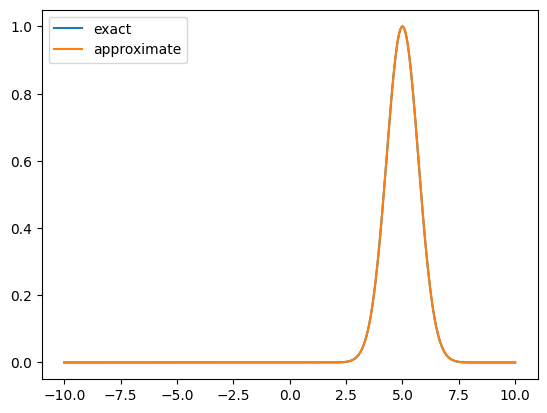

In [12]:
def u_exact(x, t, c):
    return np.exp(-(x-(c*t))**2)

def test_wave_equation():

# exact solution at the discrete grid points
    k = 12
    L = 10
    M = 2**k
    N = 1100
    c = 1
    a = -L
    b = L
    T = L/(2*c)
    t = 5

    h = (b-a)/M
    xs = [a + i * h for i in range(M + 1)]
    U_exact = [u_exact(x,c,t) for x in xs]
# approximate solution
    U_approx = solve_wave_equation()

# plot solutions
    plt.plot(xs, U_exact, label="exact")
    plt.plot(xs, U_approx[:, -1], label="approximate")
    plt.legend()
    plt.show()

test_wave_equation()

### Question 3
Let
	      \begin{equation}
		      e_k := \max_{0\leq i \leq M} |U_i^N - u(t_N,x_i)|
	      \end{equation}
	      denote the discrete error at the final time for mesh refinement level $k$, where we recall that $M = 2^k$.
	      Create a log--log plot of $e_k$ versus the mesh size $h_k := 2L/M = L / 2^{k-1}$ for $k = 10,11,12$.

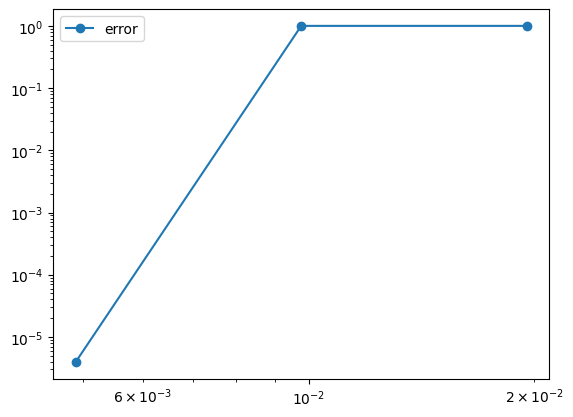

In [18]:
def compute_errors():
  L = 10
  a = -L
  b = L
  c = 1
  k_vals = [10, 11, 12]
  h_vals = []
  errors = []

  for k in k_vals:
    M = 2**k
    h = (b-a)/M
    h_vals.append(h)
    T = L/(2*c)
    xs = [a + i*h for i in range(M+1)]

    U = solve_wave_equation()

    U_final = U[:, -1]

    U_exact_vals = [u_exact(x, T, c) for x in xs]

    E_M = max(abs(U_exact_vals[i]-U_final[i]) for i in range(M+1))
    #r2 = np.log(E_M[3]-E_M[2])
    #print(r2)
    errors.append(E_M)
  return h_vals, errors

h_vals, errors = compute_errors()
plt.loglog(h_vals, errors, 'o-', label="error")
plt.legend()
plt.show()



### Question 4
Make an animation of your approximate solution $U_i^n$.

In [ ]:
def make_animation():

### Question 5
Now set $f(t,x) = 0$ and $v^0 = 0$.
	      Experiment with different periodic initial conditions $u^0$.
	      Take snapshots of your simulations and create animations over the circle in 3d.

In [ ]:
def animate_over_circle():